In [27]:
import pandas as pd
pd.set_option('display.max_columns', None)
import geopandas
import folium
#import contextily
import matplotlib.pyplot as plt
import rasterio

In [28]:
fires_df = pd.read_csv(r"C:\Users\jezkn\OneDrive\Documents\Birkbeck\Work\MSc Project\Wildfire Project\Outputs\ML_input.csv")

In [29]:
fires_df['NDVI'] = ((fires_df['SR_B5'] - fires_df['SR_B4']) / (fires_df['SR_B5'] + fires_df['SR_B4']))

In [30]:
fires_40k = fires_df[fires_df["Distance_To_Urban"] < 40000]
fires_40k.head()

,Unnamed: 0,FIRE_ID,Distance_To_Urban,Direction_To_Urban,Month,LandCover,SR_B4,SR_B5,DEM,aspect,hillshade,slope,bi,erc,eto,fm100,fm1000,pr,rmax,rmin,tmmn,tmmx,vpd,vs,Y,NDVI
0,0,CA3447311836820191024,0.637898,-102.199370,10,22,9707.0,13340.0,575.285034,287.0,221.0,14.0,64.000000,85.000000,4.700000,5.600000,7.200000,0.0,39.799999,7.600000,288.399994,303.899994,2.450000,2.700000,1,0.157634
1,1,NM3590710632420000505,13.607459,126.823521,5,52,11703.0,9768.0,2272.069824,141.0,170.0,5.0,59.550529,71.656822,6.771932,6.400834,9.868289,0.0,36.088242,10.707878,282.998199,301.213226,2.078370,3.273973,1,-0.090122
2,2,OK3546409729520090409,33.682012,-80.635225,4,21,16033.0,17501.0,365.482056,327.0,184.0,2.0,49.547791,55.544960,5.745282,7.389025,13.088677,0.0,38.997360,17.050798,276.025055,297.780701,1.390369,4.278914,1,0.043776
3,3,CA3309511719319961021,41.825166,163.762178,10,21,13500.0,16612.0,220.747681,248.0,211.0,11.0,31.030558,36.643394,3.269728,16.186947,15.099339,0.0,93.948326,36.480064,283.264709,296.451874,0.915196,2.810570,1,0.103348
4,4,FL2639608141719890407,47.080540,-2.021671,4,23,17700.0,17006.0,7.891233,82.0,178.0,1.0,27.302124,29.657053,5.591947,16.836201,18.122858,0.0,100.000000,26.371464,284.354492,302.547577,1.145852,3.293140,1,-0.019997


In [31]:
fires_10k = fires_df[fires_df["Distance_To_Urban"] < 10000]
fires_10k["Y"].value_counts()

Y
0    2269
1     505
Name: count, dtype: int64

In [69]:
fires_2500m = fires_df[fires_df["Distance_To_Urban"] < 2500]
fires_2500m["Y"].value_counts()

Y
1    352
0    180
Name: count, dtype: int64

In [70]:
fires_40k["Y"].value_counts()

Y
0    23680
1      535
Name: count, dtype: int64

In [88]:
fires = fires_10k.drop(columns=["Unnamed: 0","FIRE_ID", "SR_B4", "SR_B5"])
fires_corr = fires.corr()
fires_corr

,Distance_To_Urban,Direction_To_Urban,Month,LandCover,DEM,aspect,hillshade,slope,bi,erc,eto,fm100,fm1000,pr,rmax,rmin,tmmn,tmmx,vpd,vs,Y,NDVI
Distance_To_Urban,1.000000,-0.009964,-0.038010,-0.029364,0.078684,-0.002179,-0.009118,-0.011546,0.021770,0.027636,0.006738,-0.040124,-0.019737,-0.004886,-0.035334,-0.043486,-0.070023,-0.033819,-0.000592,0.018569,-0.551740,0.005437
Direction_To_Urban,-0.009964,1.000000,-0.022600,0.032382,-0.031610,-0.021406,-0.007787,-0.029775,-0.053236,-0.079269,-0.038150,0.077529,0.074888,0.012890,0.061469,0.081814,0.005898,-0.038103,-0.067954,0.025947,0.018538,-0.016691
Month,-0.038010,-0.022600,1.000000,-0.131820,0.179725,0.029145,0.046157,0.337309,0.105437,0.198974,-0.048490,-0.150611,-0.217062,-0.046235,-0.161286,-0.192019,0.109298,0.122425,0.174595,-0.188138,0.119333,0.000202
LandCover,-0.029364,0.032382,-0.131820,1.000000,-0.223925,-0.041423,-0.048653,-0.319898,-0.119102,-0.158956,0.084663,0.204389,0.144539,0.098578,0.215044,0.246310,0.233180,0.134226,-0.047621,0.050513,-0.028266,0.080893
DEM,0.078684,-0.031610,0.179725,-0.223925,1.000000,-0.020470,-0.049033,0.372138,0.463515,0.623134,0.233299,-0.613646,-0.624518,-0.093467,-0.572307,-0.558230,-0.107740,0.053232,0.296154,-0.043621,0.031191,0.013074
aspect,-0.002179,-0.021406,0.029145,-0.041423,-0.020470,1.000000,0.562652,0.016790,-0.032638,-0.022087,-0.029692,-0.007670,0.025051,-0.007959,-0.013027,-0.005874,-0.016697,-0.016284,-0.007196,-0.028886,0.015125,0.006536
hillshade,-0.009118,-0.007787,0.046157,-0.048653,-0.049033,0.562652,1.000000,0.022797,-0.032188,-0.047199,-0.049435,0.029267,0.051089,-0.005285,0.024983,0.006488,-0.025853,-0.026301,-0.033478,0.002021,0.003161,-0.026869
slope,-0.011546,-0.029775,0.337309,-0.319898,0.372138,0.016790,0.022797,1.000000,0.177385,0.277418,-0.018226,-0.280331,-0.277589,-0.113164,-0.289970,-0.275343,-0.079193,-0.011705,0.133916,-0.148233,0.102089,-0.057397
bi,0.021770,-0.053236,0.105437,-0.119102,0.463515,-0.032638,-0.032188,0.177385,1.000000,0.823864,0.501058,-0.732388,-0.706684,-0.337032,-0.656529,-0.671489,0.016997,0.192549,0.482250,0.266870,0.094299,0.098692
erc,0.027636,-0.079269,0.198974,-0.158956,0.623134,-0.022087,-0.047199,0.277418,0.823864,1.000000,0.584081,-0.945212,-0.961105,-0.246167,-0.826922,-0.815980,0.197341,0.406017,0.730932,-0.085385,0.103525,0.114734


In [89]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

In [90]:
from sklearn.model_selection import train_test_split

In [91]:
y = fires["Y"]
X = fires.drop(columns=["Y"])

In [92]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

In [93]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, verbose=1, random_state=26, class_weight='balanced')

In [94]:
X_train = scaler.fit_transform(X_train)
X_model = rf_model.fit(X_train, y_train)

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.7s finished


In [95]:
X_test = scaler.transform(X_test)
rf_predictions = rf_model.predict(X_test)

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.0s finished


In [96]:
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

f1_score_rf = f1_score(y_test, rf_predictions, average=None, zero_division=0)
report_rf = classification_report(y_test, rf_predictions,zero_division=0)

In [97]:
print(f1_score_rf)

[0.93316359 0.59770115]


In [98]:
print(report_rf)

              precision    recall  f1-score   support

           0       0.90      0.97      0.93       754
           1       0.79      0.48      0.60       162

    accuracy                           0.89       916
   macro avg       0.84      0.73      0.77       916
weighted avg       0.88      0.89      0.87       916



<Axes: >

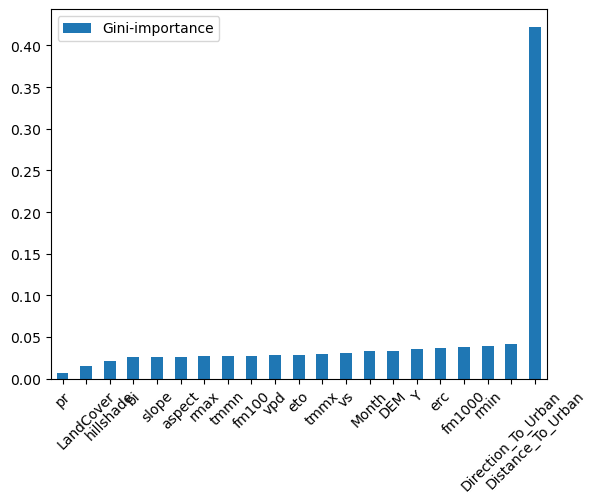

In [99]:
# https://stackoverflow.com/questions/41900387/mapping-column-names-to-random-forest-feature-importances

%matplotlib inline
#do code to support model
#"data" is the X dataframe and model is the SKlearn object

feats = {} # a dict to hold feature_name: feature_importance
for feature, importance in zip(fires.columns, rf_model.feature_importances_):
    feats[feature] = importance #add the name/value pair 

importances = pd.DataFrame.from_dict(feats, orient='index').rename(columns={0: 'Gini-importance'})
importances.sort_values(by='Gini-importance').plot(kind='bar', rot=45)

In [100]:
import sklearn
from sklearn.linear_model import LogisticRegression

fires_lr = fires[fires["Distance_To_Urban"].notna()]

X = fires_lr[['Distance_To_Urban']]
y = fires_lr[['Y']]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

reg = LogisticRegression().fit(X_train, y_train)
reg.score(X, y)
reg.coef_
reg.intercept_

C:\Users\jezkn\Anaconda3\envs\geo_env2\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


array([1.64397791])

In [101]:
reg_predictions = reg.predict(X_test)

In [102]:
f1_score_reg = f1_score(y_test, reg_predictions, average=None, zero_division=0)
report_reg = classification_report(y_test, reg_predictions,zero_division=0)

In [103]:
print(f1_score_reg)

[0.93315858 0.66666667]


In [104]:
print(report_reg)

              precision    recall  f1-score   support

           0       0.92      0.94      0.93       754
           1       0.71      0.63      0.67       162

    accuracy                           0.89       916
   macro avg       0.82      0.79      0.80       916
weighted avg       0.88      0.89      0.89       916

